# Install Library

In [ ]:
!pip install mealpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.8/168.8 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.3/423.3 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 110.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy

In [ ]:
!pip install opfunu

# Import Library

In [ ]:
# fundamental libraries
import os
import time
import numpy as np
import pandas as pd
from pathlib import Path

# mealpy library
from mealpy import Multitask

from typing import List, Dict

# Connected to Drive

In [17]:
from google.colab import drive

# This will prompt for authorization.
# Make sure to follow the instructions and paste the authorization code.
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
path = "/content/drive/My Drive/Revision/"

# Define Necessary Function

## Benchmark Function

In [ ]:
import sys
sys.path.append(path)

from benchmark_functions import classical_test_function
from benchmark_functions import cec20_test_function_with_bias
from benchmark_functions import cec22_test_function_with_bias

## Define Problems

In [ ]:
# Classical Test Function
Fnames, Ffunctions, Fproblems, Flatexs = classical_test_function()

In [ ]:
# Composite (CEC20) Test Function
C20names_50, C20functions_50, C20problems_50, C20latexs_50 = cec20_test_function_with_bias(dimension=50)
C20names_100, C20functions_100, C20problems_100, C20latexs_100 = cec20_test_function_with_bias(dimension=100)

In [ ]:
# Composite (CEC22) Test Function
C22names_10, C22functions_10, C22problems_10, C22latexs_10 = cec22_test_function_with_bias(dimension=10)
C22names_20, C22functions_20, C22problems_20, C22latexs_20 = cec22_test_function_with_bias(dimension=20)

# Define Models

In [ ]:
from optimizers import NHO

# Selected Benchmark Functions

In [ ]:
def select_problem_list(name_list, problem_list, selected_index):
    selected_names = []
    selected_problems = []

    for idx in selected_index:
        selected_names.append(name_list[idx])
        selected_problems.append(problem_list[idx])

    return selected_names, selected_problems

In [ ]:
# 0-based index kullanılmıştır.
# İstersen buradaki indeksleri değiştirerek farklı fonksiyonlar seçebilirsin.

classic_selected_index = [0, 6, 9, 14]
cec22_10_selected_index = [2, 4, 8, 11]
cec22_20_selected_index = [2, 4, 8, 11]

Fnames_sel, Fproblems_sel = select_problem_list(Fnames, Fproblems, classic_selected_index)
C22names_10_sel, C22problems_10_sel = select_problem_list(C22names_10, C22problems_10, cec22_10_selected_index)
C22names_20_sel, C22problems_20_sel = select_problem_list(C22names_20, C22problems_20, cec22_20_selected_index)

print("Selected Classical Functions:", Fnames_sel)
print("Selected CEC22-10 Functions:", C22names_10_sel)
print("Selected CEC22-20 Functions:", C22names_20_sel)

Selected Classical Functions: ['F1', 'F7', 'F10', 'F15']
Selected CEC22-10 Functions: ['C3', 'C5', 'C9', 'C12']
Selected CEC22-20 Functions: ['C3', 'C5', 'C9', 'C12']


# Parameter Sensitivity Analysis

In [ ]:
# Hızlı çalışma için 3 kullanılabilir.
# Daha güvenli sonuç için 5 önerilir.
trial = 5
n_workers = 4

sensitivity_results = []

In [ ]:
def modify_problem_dicts(problem_list):
    modified_problems = []
    for problem_dict in problem_list:
        new_problem_dict = problem_dict.copy()
        if "fit_func" in new_problem_dict:
            new_problem_dict["obj_func"] = new_problem_dict.pop("fit_func")
        modified_problems.append(new_problem_dict)
    return modified_problems

In [ ]:
def run_selected_sensitivity_suite(suite_name, dimension, problem_list, parameter_grid):

    modified_problems = modify_problem_dicts(problem_list)

    for params in parameter_grid:
        epoch = params.get("epoch", 300)
        pop_size = params.get("pop_size", 50)

        nho_params = params.copy()
        nho_params.pop("case_name", None)

        case_name = params.get("case_name", "case")

        nho = NHO(**nho_params)

        save_folder = path + f"history/sensitivity_selected/{suite_name}-{dimension}D/{case_name}"
        os.makedirs(save_folder, exist_ok=True)

        start_time = time.time()
        multitask = Multitask(algorithms=[nho], problems=modified_problems, n_workers=n_workers)
        multitask.execute(n_trials=trial, save_path=save_folder, save_as="csv", save_convergence=True, verbose=True)
        runtime = time.time() - start_time

        row = {
            "algorithm": "NHO",
            "suite": suite_name,
            "dimension": dimension,
            "case_name": case_name,
            "trial": trial,
            "runtime": runtime,
            "save_folder": save_folder
        }
        row.update(nho_params)
        sensitivity_results.append(row)

        pd.DataFrame(sensitivity_results).to_csv(path + "history/sensitivity_selected/sensitivity_selected_runtime.csv", index=False)
        print("Completed", suite_name, dimension, case_name, "Runtime:", runtime)

## Parameter Grid

In [ ]:
# Tek seferde çok parametre değiştirmiyoruz.
# Her satır yalnızca bir parametre etkisini görmeye yöneliktir.

base_epoch = 300
base_pop_size = 50

sensitivity_parameter_grid = [
    {"case_name": "baseline", "epoch": base_epoch, "pop_size": base_pop_size},

    {"case_name": "lambda_D_010", "epoch": base_epoch, "pop_size": base_pop_size, "lambda_D": 0.10},
    {"case_name": "lambda_D_030", "epoch": base_epoch, "pop_size": base_pop_size, "lambda_D": 0.30},
    {"case_name": "lambda_D_050", "epoch": base_epoch, "pop_size": base_pop_size, "lambda_D": 0.50},

    {"case_name": "lambda_S_010", "epoch": base_epoch, "pop_size": base_pop_size, "lambda_S": 0.10},
    {"case_name": "lambda_S_020", "epoch": base_epoch, "pop_size": base_pop_size, "lambda_S": 0.20},
    {"case_name": "lambda_S_040", "epoch": base_epoch, "pop_size": base_pop_size, "lambda_S": 0.40},

    {"case_name": "lambda_C_010", "epoch": base_epoch, "pop_size": base_pop_size, "lambda_C": 0.10},
    {"case_name": "lambda_C_030", "epoch": base_epoch, "pop_size": base_pop_size, "lambda_C": 0.30},
    {"case_name": "lambda_C_050", "epoch": base_epoch, "pop_size": base_pop_size, "lambda_C": 0.50},

    {"case_name": "p_elite_010", "epoch": base_epoch, "pop_size": base_pop_size, "p_elite": 0.10},
    {"case_name": "p_elite_020", "epoch": base_epoch, "pop_size": base_pop_size, "p_elite": 0.20},
    {"case_name": "p_elite_030", "epoch": base_epoch, "pop_size": base_pop_size, "p_elite": 0.30},
]

## Classical Selected Functions

In [ ]:
if __name__ == "__main__":
    run_selected_sensitivity_suite("classic_selected", 2, Fproblems_sel, sensitivity_parameter_grid)

Solving problem: Ackley2 using algorithm: NHO, on the: 1 trial


KeyboardInterrupt: 

## CEC22-10 Selected Functions

In [ ]:
if __name__ == "__main__":
    run_selected_sensitivity_suite("CEC22_selected", 10, C22problems_10_sel, sensitivity_parameter_grid)

Solving problem: F32022 using algorithm: NHO, on the: 1 trial
Solving problem: F32022 using algorithm: NHO, on the: 2 trial
Solving problem: F32022 using algorithm: NHO, on the: 3 trial
Solving problem: F32022 using algorithm: NHO, on the: 4 trial
Solving problem: F32022 using algorithm: NHO, on the: 5 trial
Solving problem: F52022 using algorithm: NHO, on the: 1 trial
Solving problem: F52022 using algorithm: NHO, on the: 2 trial
Solving problem: F52022 using algorithm: NHO, on the: 3 trial
Solving problem: F52022 using algorithm: NHO, on the: 4 trial
Solving problem: F52022 using algorithm: NHO, on the: 5 trial
Solving problem: F92022 using algorithm: NHO, on the: 1 trial
Solving problem: F92022 using algorithm: NHO, on the: 2 trial
Solving problem: F92022 using algorithm: NHO, on the: 3 trial
Solving problem: F92022 using algorithm: NHO, on the: 4 trial
Solving problem: F92022 using algorithm: NHO, on the: 5 trial
Solving problem: F122022 using algorithm: NHO, on the: 1 trial
Solving

## CEC22-20 Selected Functions

In [ ]:
# Zaman kısıtlıysa bu hücreyi çalıştırmayabilirsin.
# Reviewer cevabı için 10D çoğu durumda yeterlidir.

if __name__ == "__main__":
    run_selected_sensitivity_suite("CEC22_selected", 20, C22problems_20_sel, sensitivity_parameter_grid)

Solving problem: F32022 using algorithm: NHO, on the: 1 trial
Solving problem: F32022 using algorithm: NHO, on the: 2 trial
Solving problem: F32022 using algorithm: NHO, on the: 3 trial
Solving problem: F32022 using algorithm: NHO, on the: 4 trial
Solving problem: F32022 using algorithm: NHO, on the: 5 trial
Solving problem: F52022 using algorithm: NHO, on the: 1 trial
Solving problem: F52022 using algorithm: NHO, on the: 2 trial
Solving problem: F52022 using algorithm: NHO, on the: 3 trial
Solving problem: F52022 using algorithm: NHO, on the: 4 trial
Solving problem: F52022 using algorithm: NHO, on the: 5 trial
Solving problem: F92022 using algorithm: NHO, on the: 1 trial
Solving problem: F92022 using algorithm: NHO, on the: 2 trial
Solving problem: F92022 using algorithm: NHO, on the: 3 trial
Solving problem: F92022 using algorithm: NHO, on the: 4 trial
Solving problem: F92022 using algorithm: NHO, on the: 5 trial
Solving problem: F122022 using algorithm: NHO, on the: 1 trial
Solving

# Summary


SUMMARY TABLE
benchmark parameter  parameter_value     setting_label    CEC22-10D  \
0          lambda_C              0.1  $\lambda_C$=0.10  1714.120224   
1          lambda_C              0.3  $\lambda_C$=0.30  1673.406000   
2          lambda_C              0.5  $\lambda_C$=0.50  1707.648157   
3          lambda_D              0.1  $\lambda_D$=0.10  1741.064185   
4          lambda_D              0.3  $\lambda_D$=0.30  1691.576910   
5          lambda_D              0.5  $\lambda_D$=0.50  1696.002486   
6          lambda_S              0.1  $\lambda_S$=0.10  1666.209409   
7          lambda_S              0.2  $\lambda_S$=0.20  1719.473958   
8          lambda_S              0.4  $\lambda_S$=0.40  1703.138387   
9           p_elite              0.1  $p_{elite}$=0.10  1726.879376   
10          p_elite              0.2  $p_{elite}$=0.20  1712.011612   
11          p_elite              0.3  $p_{elite}$=0.30  1752.390341   

benchmark    CEC22-20D  Classic-2D  
0          1803.428700  

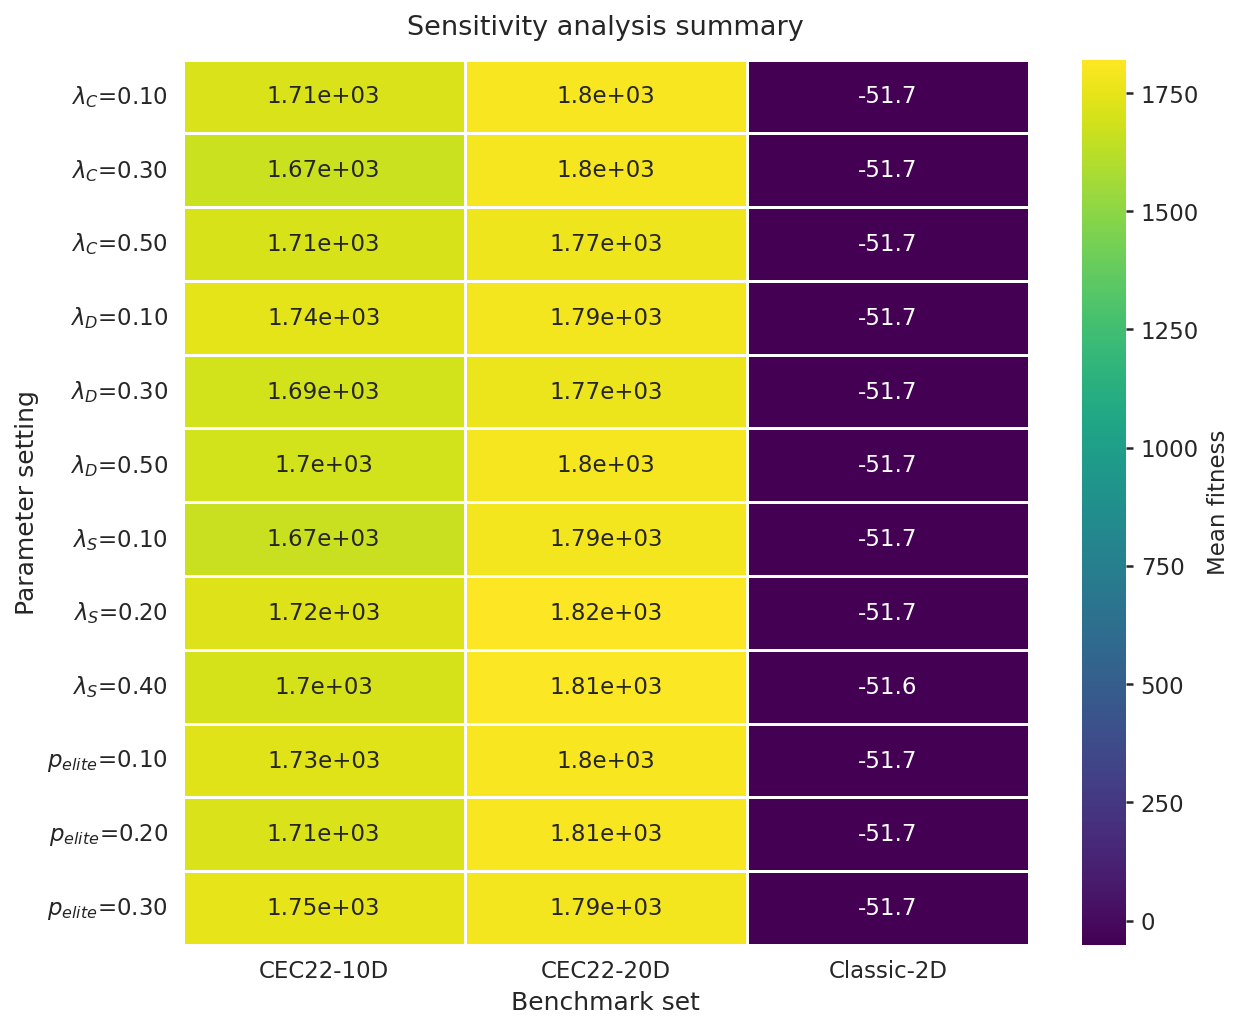

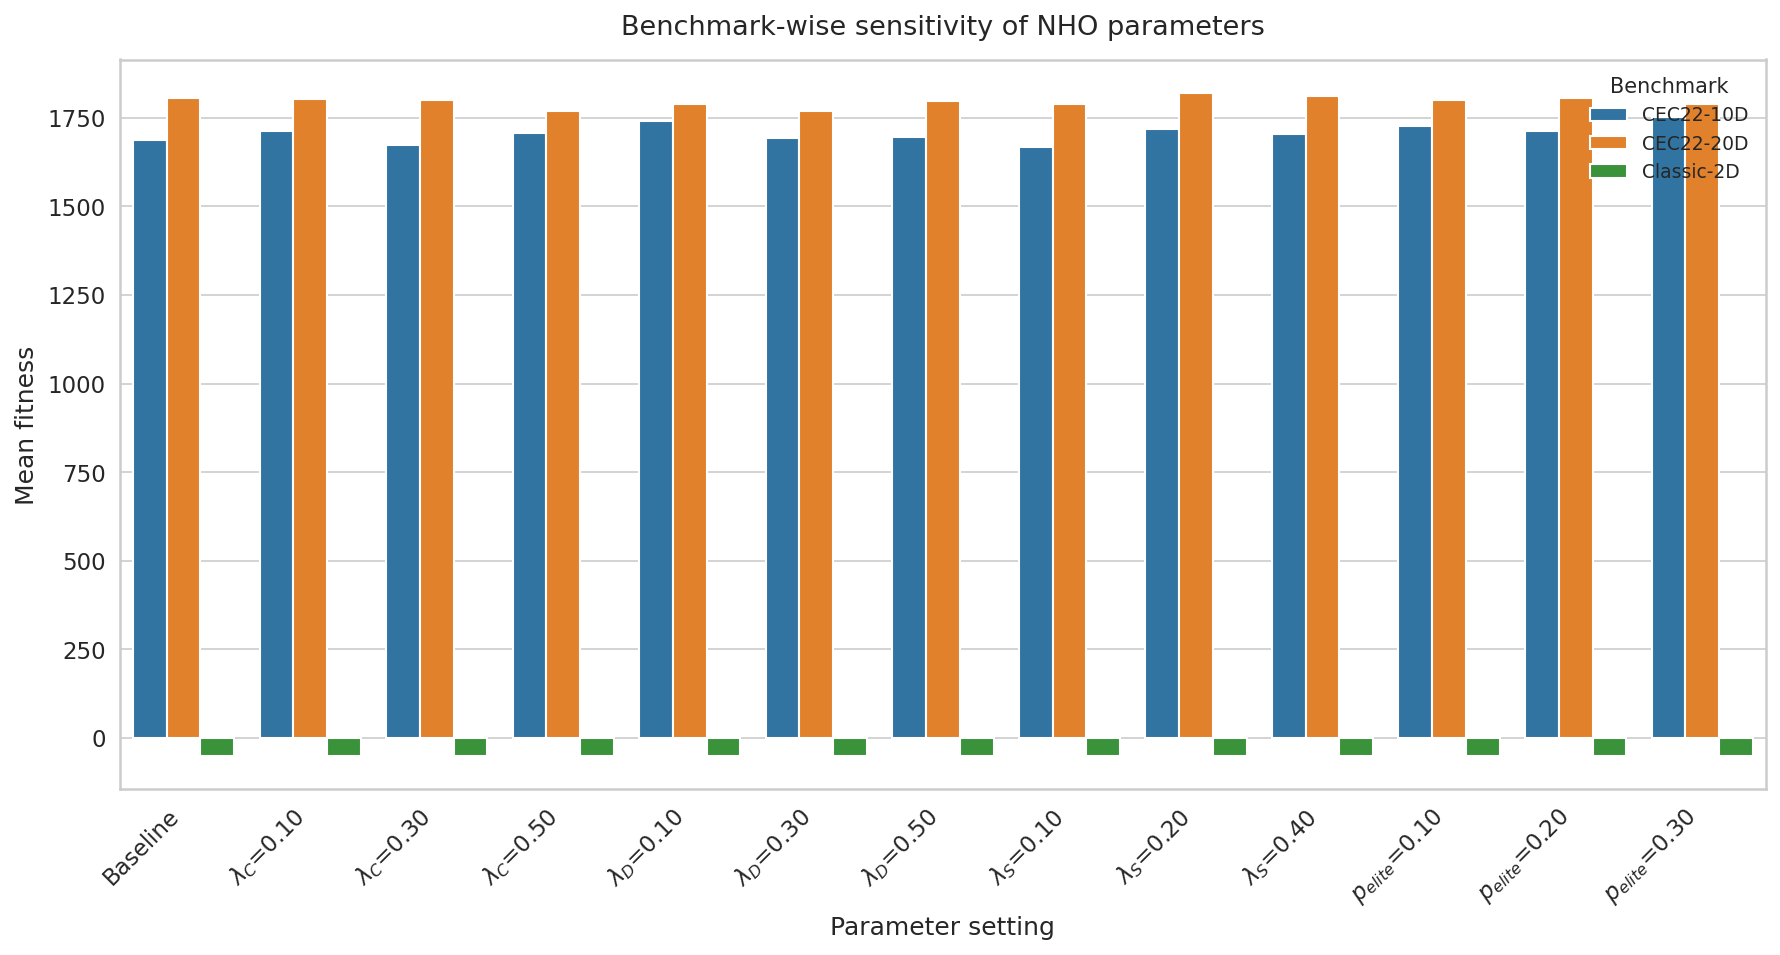

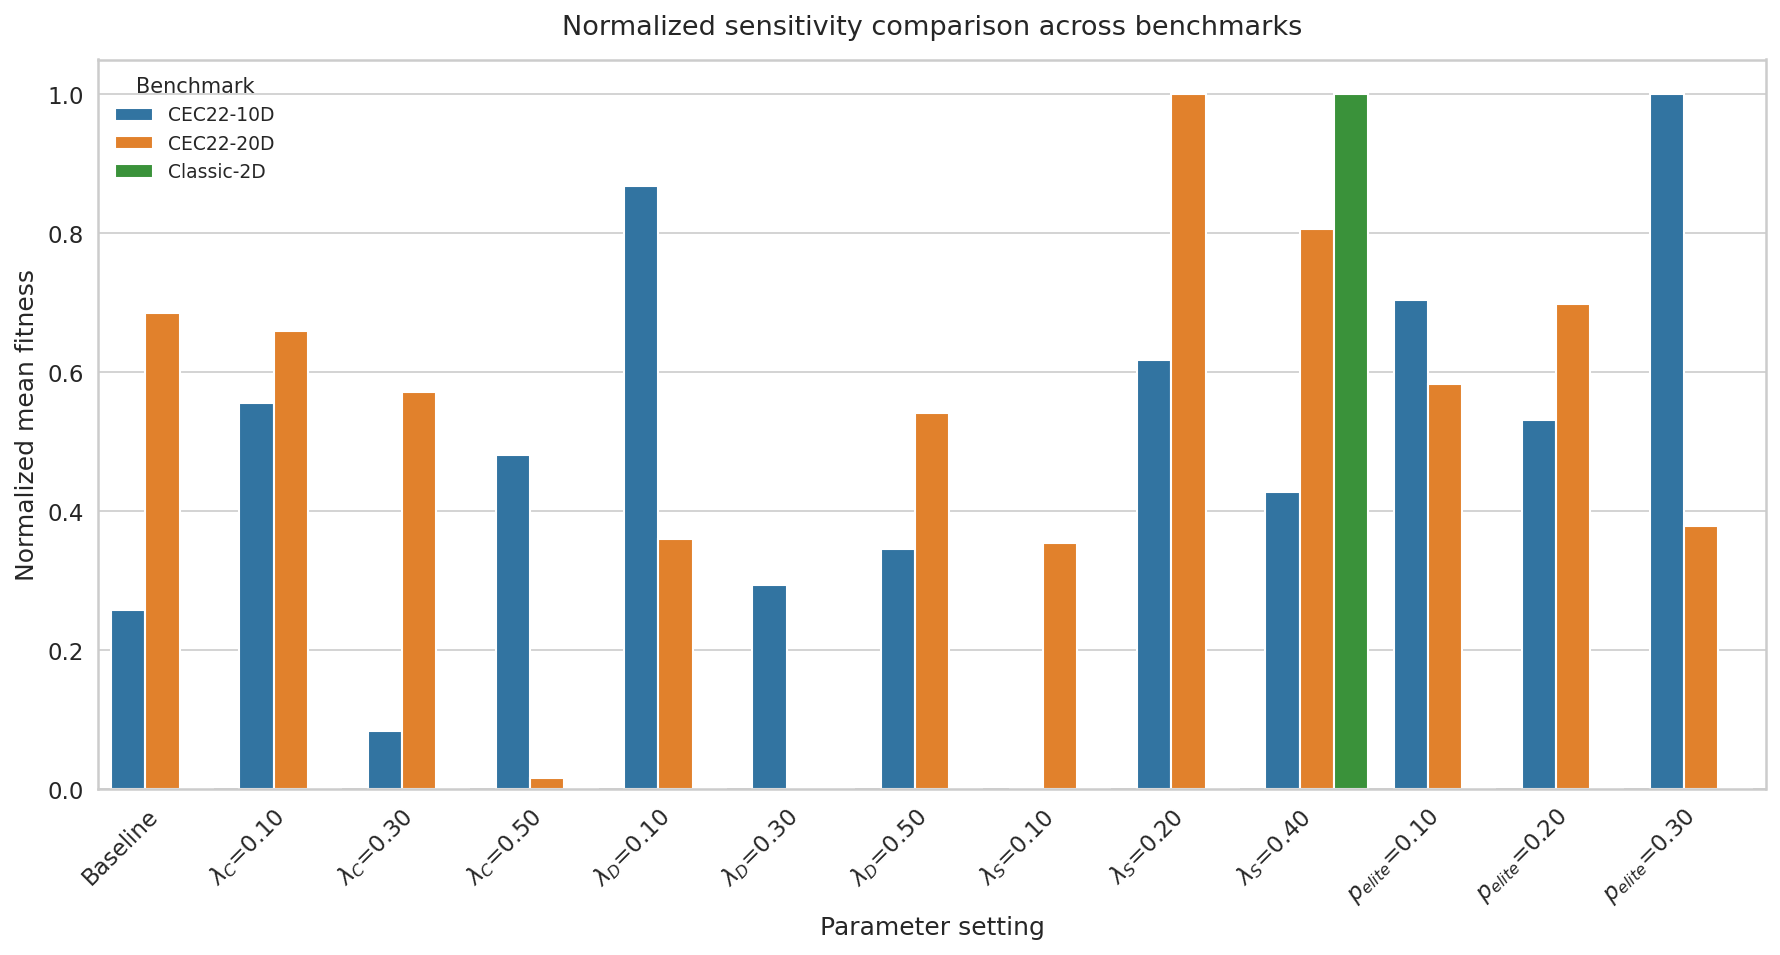

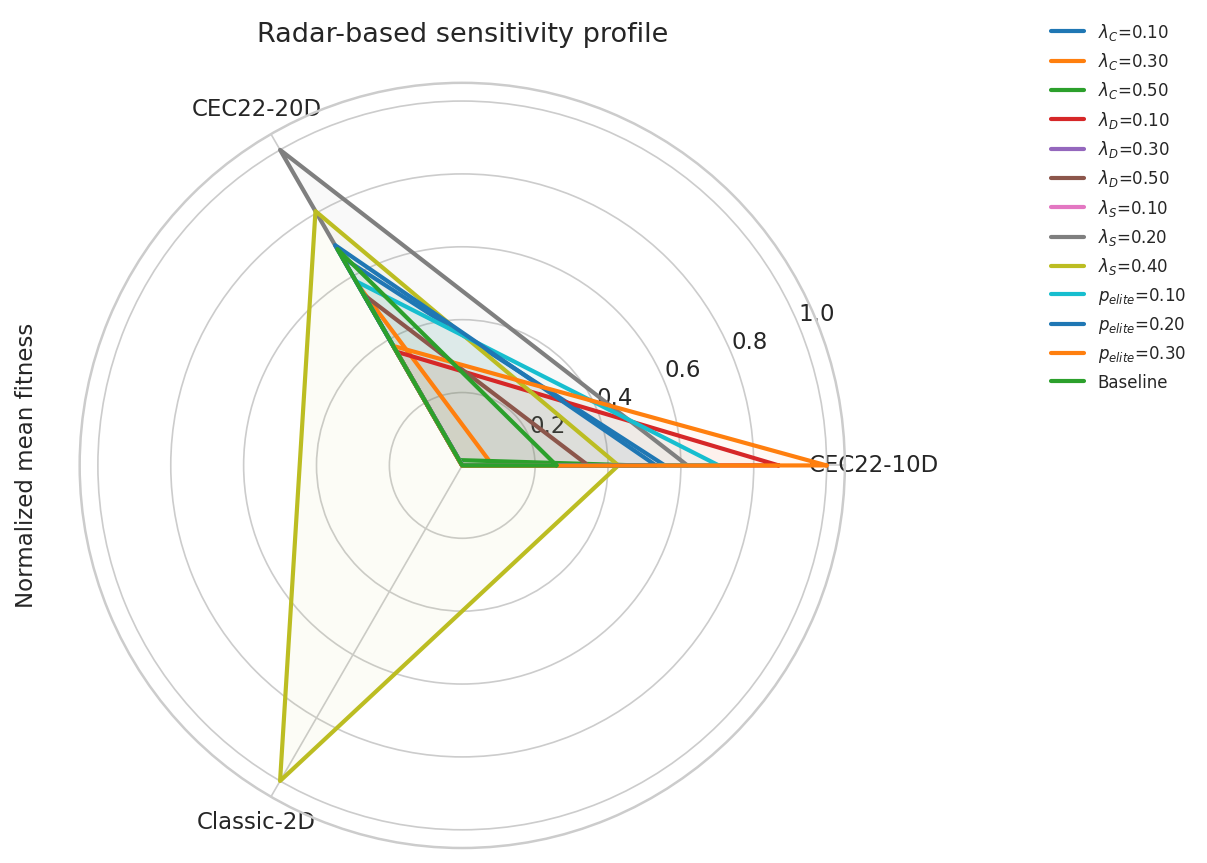

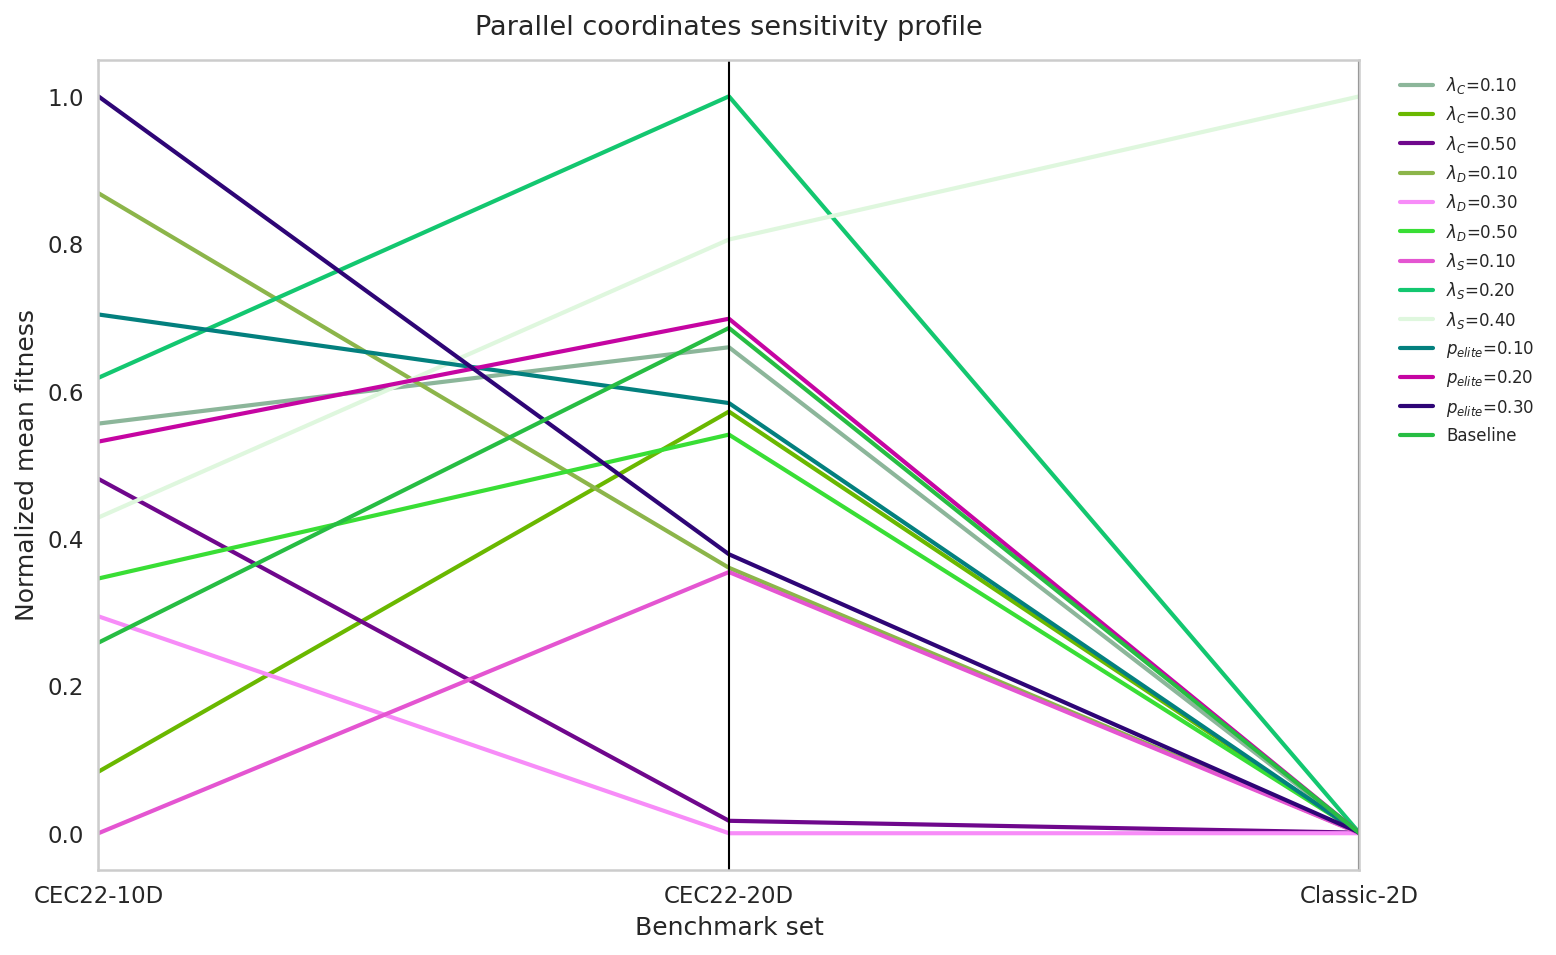

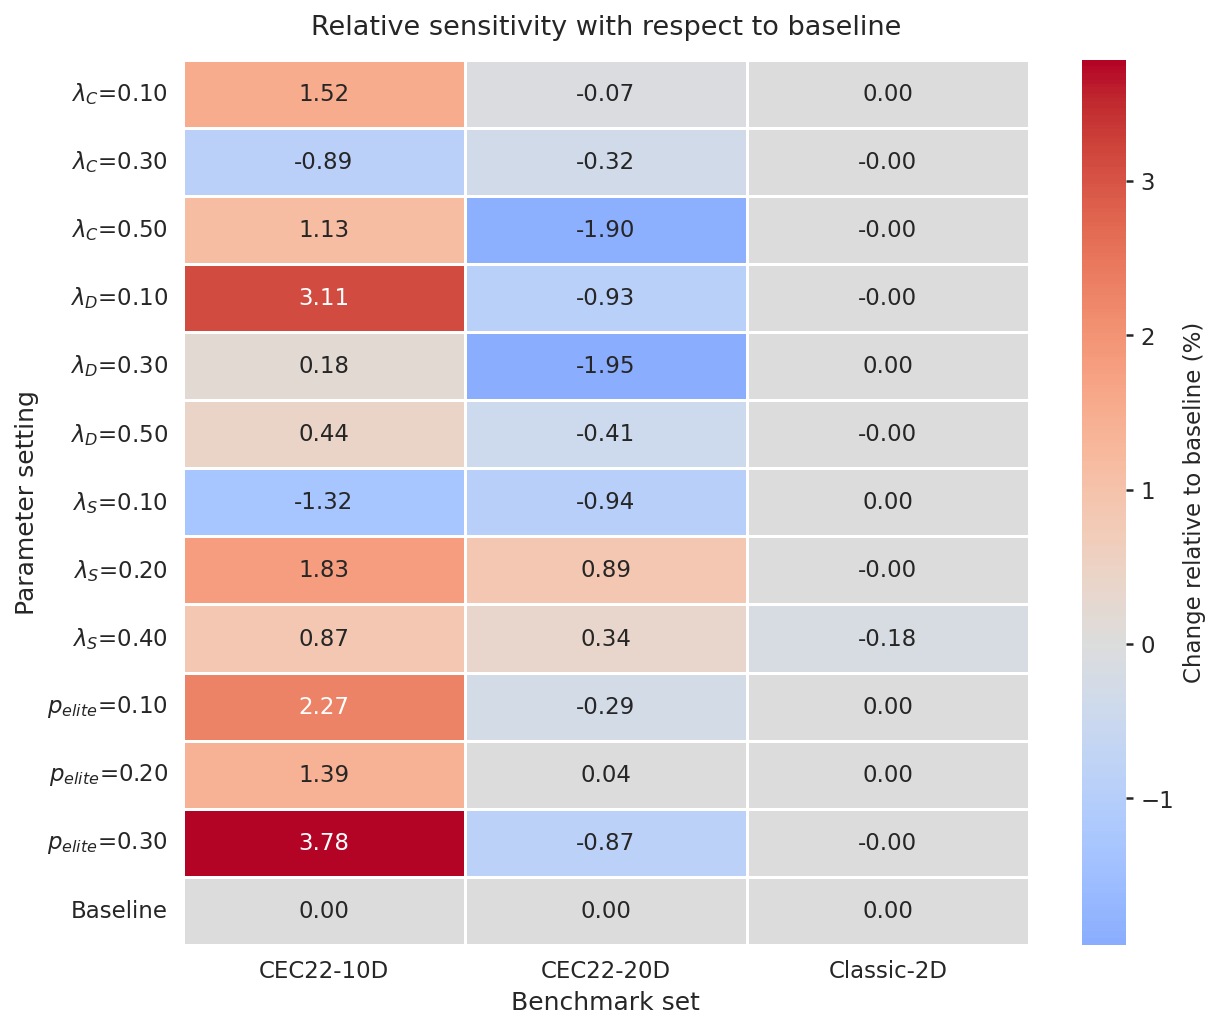


All tables and figures saved successfully.
Output directory: /content/drive/My Drive/Revision/history/sensitivity_analysis/summary_outputs


In [22]:

# ============================================================
# NHO SENSITIVITY ANALYSIS
# Q1 JOURNAL STYLE SUMMARY TABLE + FIGURES
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
from pandas.plotting import parallel_coordinates

# ============================================================
# 1. PATH SETTINGS
# ============================================================

path = "/content/drive/My Drive/Revision/history/sensitivity_analysis"
save_dir = os.path.join(path, "summary_outputs")
os.makedirs(save_dir, exist_ok=True)

# ============================================================
# 2. Q1 JOURNAL STYLE
# ============================================================

mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.size"] = 11
mpl.rcParams["axes.linewidth"] = 1.2
mpl.rcParams["xtick.major.width"] = 1.2
mpl.rcParams["ytick.major.width"] = 1.2
mpl.rcParams["legend.frameon"] = False
mpl.rcParams["figure.dpi"] = 150
mpl.rcParams["savefig.dpi"] = 600

sns.set_style("whitegrid")


# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def benchmark_label(folder_name):
    name = folder_name.lower()

    if "cec22" in name and "10" in name:
        return "CEC22-10D"
    elif "cec22" in name and "20" in name:
        return "CEC22-20D"
    elif "classic" in name:
        return "Classic-2D"
    else:
        return folder_name


def parse_case_label(case_name):
    if case_name == "baseline":
        return "Baseline", "baseline", np.nan

    patterns = {
        "lambda_C": r"lambda_C_(\d+)",
        "lambda_D": r"lambda_D_(\d+)",
        "lambda_S": r"lambda_S_(\d+)",
        "p_elite": r"p_elite_(\d+)"
    }

    for param, pattern in patterns.items():
        match = re.search(pattern, case_name)
        if match:
            raw_val = int(match.group(1))
            val = raw_val / 100

            if param == "lambda_C":
                label = rf"$\lambda_C$={val:.2f}"
            elif param == "lambda_D":
                label = rf"$\lambda_D$={val:.2f}"
            elif param == "lambda_S":
                label = rf"$\lambda_S$={val:.2f}"
            elif param == "p_elite":
                label = rf"$p_{{elite}}$={val:.2f}"

            return label, param, val

    return case_name, "unknown", np.nan


def read_best_fit_file(file_path):
    df = pd.read_csv(file_path)

    numeric_df = df.select_dtypes(include=[np.number])

    if numeric_df.empty:
        raise ValueError(f"No numeric columns found in: {file_path}")

    values = numeric_df.values.flatten()
    values = values[~np.isnan(values)]

    return {
        "mean": np.mean(values),
        "std": np.std(values),
        "min": np.min(values),
        "max": np.max(values),
        "median": np.median(values),
        "n_values": len(values)
    }


def save_current_figure(filename_base):
    for ext in ["pdf", "png", "tiff"]:
        plt.savefig(
            os.path.join(save_dir, f"{filename_base}.{ext}"),
            bbox_inches="tight",
            dpi=600
        )


# ============================================================
# 4. LOAD ALL SENSITIVITY RESULTS
# ============================================================

records = []

for benchmark_folder in sorted(os.listdir(path)):
    benchmark_path = os.path.join(path, benchmark_folder)

    if not os.path.isdir(benchmark_path):
        continue

    if benchmark_folder == "summary_outputs":
        continue

    for case_name in sorted(os.listdir(benchmark_path)):
        best_fit_file = os.path.join(
            benchmark_path,
            case_name,
            "best_fit",
            "NHO_best_fit.csv"
        )

        if not os.path.exists(best_fit_file):
            continue

        setting_label, parameter, parameter_value = parse_case_label(case_name)
        stats = read_best_fit_file(best_fit_file)

        records.append({
            "benchmark": benchmark_label(benchmark_folder),
            "benchmark_folder": benchmark_folder,
            "case_name": case_name,
            "parameter": parameter,
            "parameter_value": parameter_value,
            "setting_label": setting_label,
            "mean_fitness": stats["mean"],
            "std_fitness": stats["std"],
            "min_fitness": stats["min"],
            "max_fitness": stats["max"],
            "median_fitness": stats["median"],
            "n_values": stats["n_values"]
        })

summary_long = pd.DataFrame(records)

if summary_long.empty:
    raise FileNotFoundError(
        "No NHO_best_fit.csv files found. Please check the path structure."
    )

# ============================================================
# 5. ORDER SETTINGS
# ============================================================

parameter_order = {
    "baseline": 0,
    "lambda_C": 1,
    "lambda_D": 2,
    "lambda_S": 3,
    "p_elite": 4,
    "unknown": 99
}

benchmark_order = {
    "CEC22-10D": 0,
    "CEC22-20D": 1,
    "Classic-2D": 2
}

summary_long["parameter_order"] = summary_long["parameter"].map(parameter_order).fillna(99)
summary_long["benchmark_order"] = summary_long["benchmark"].map(benchmark_order).fillna(99)
summary_long["parameter_value_order"] = summary_long["parameter_value"].fillna(-1)

summary_long = summary_long.sort_values(
    ["parameter_order", "parameter_value_order", "benchmark_order"]
)

# ============================================================
# 6. CREATE ONE SUMMARY TABLE
# ============================================================

summary_table = summary_long.pivot_table(
    index=["parameter", "parameter_value", "setting_label"],
    columns="benchmark",
    values="mean_fitness",
    aggfunc="mean"
).reset_index()

# Better column order
wanted_cols = ["parameter", "parameter_value", "setting_label",
               "CEC22-10D", "CEC22-20D", "Classic-2D"]

summary_table = summary_table[[c for c in wanted_cols if c in summary_table.columns]]

# Save tables
summary_long.to_excel(
    os.path.join(save_dir, "Sensitivity_Summary_Long.xlsx"),
    index=False
)

summary_table.to_excel(
    os.path.join(save_dir, "Sensitivity_Summary_Table.xlsx"),
    index=False
)

summary_long.to_csv(
    os.path.join(save_dir, "Sensitivity_Summary_Long.csv"),
    index=False
)

summary_table.to_csv(
    os.path.join(save_dir, "Sensitivity_Summary_Table.csv"),
    index=False
)

print("\nSUMMARY TABLE")
print(summary_table)

# ============================================================
# 7. FIGURE 1 — HEATMAP
# ============================================================

heatmap_df = summary_table.set_index("setting_label")
heatmap_df = heatmap_df[[c for c in ["CEC22-10D", "CEC22-20D", "Classic-2D"] if c in heatmap_df.columns]]

plt.figure(figsize=(8.5, 7))
ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3g",
    linewidths=0.5,
    cmap="viridis",
    cbar_kws={"label": "Mean fitness"}
)

ax.set_xlabel("Benchmark set", fontsize=12)
ax.set_ylabel("Parameter setting", fontsize=12)
ax.set_title("Sensitivity analysis summary", fontsize=13, pad=12)

plt.tight_layout()
save_current_figure("Figure_1_Heatmap_Sensitivity")
plt.show()

# ============================================================
# 8. FIGURE 2 — GROUPED BARPLOT
# ============================================================

plt.figure(figsize=(12, 6.5))

ax = sns.barplot(
    data=summary_long,
    x="setting_label",
    y="mean_fitness",
    hue="benchmark",
    errorbar=None
)

ax.set_xlabel("Parameter setting", fontsize=12)
ax.set_ylabel("Mean fitness", fontsize=12)
ax.set_title("Benchmark-wise sensitivity of NHO parameters", fontsize=13, pad=12)

plt.xticks(rotation=45, ha="right")
plt.legend(title="Benchmark", fontsize=9, title_fontsize=10)

plt.tight_layout()
save_current_figure("Figure_2_Grouped_Barplot_Sensitivity")
plt.show()

# ============================================================
# 9. FIGURE 3 — NORMALIZED GROUPED BARPLOT
# Lower value is better. Values are normalized benchmark-wise.
# ============================================================

norm_df = summary_long.copy()

norm_df["normalized_fitness"] = norm_df.groupby("benchmark")["mean_fitness"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-12)
)

plt.figure(figsize=(12, 6.5))

ax = sns.barplot(
    data=norm_df,
    x="setting_label",
    y="normalized_fitness",
    hue="benchmark",
    errorbar=None
)

ax.set_xlabel("Parameter setting", fontsize=12)
ax.set_ylabel("Normalized mean fitness", fontsize=12)
ax.set_title("Normalized sensitivity comparison across benchmarks", fontsize=13, pad=12)

plt.xticks(rotation=45, ha="right")
plt.legend(title="Benchmark", fontsize=9, title_fontsize=10)

plt.tight_layout()
save_current_figure("Figure_3_Normalized_Grouped_Barplot")
plt.show()

# ============================================================
# 10. FIGURE 4 — RADAR PLOT
# Uses benchmark-wise normalized values.
# ============================================================

radar_df = norm_df.pivot_table(
    index="setting_label",
    columns="benchmark",
    values="normalized_fitness",
    aggfunc="mean"
).reset_index()

benchmark_cols = [c for c in ["CEC22-10D", "CEC22-20D", "Classic-2D"] if c in radar_df.columns]

N = len(benchmark_cols)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(8.5, 8.5))
ax = plt.subplot(111, polar=True)

for _, row in radar_df.iterrows():
    values = row[benchmark_cols].values.astype(float).tolist()
    values += values[:1]

    ax.plot(angles, values, linewidth=2, label=row["setting_label"])
    ax.fill(angles, values, alpha=0.04)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(benchmark_cols, fontsize=11)
ax.set_ylabel("Normalized mean fitness", labelpad=20)

plt.legend(
    bbox_to_anchor=(1.25, 1.10),
    loc="upper left",
    fontsize=8
)

plt.title("Radar-based sensitivity profile", fontsize=13, pad=20)

plt.tight_layout()
save_current_figure("Figure_4_Radar_Sensitivity")
plt.show()

# ============================================================
# 11. FIGURE 5 — PARALLEL COORDINATES
# Uses normalized benchmark-wise values.
# ============================================================

parallel_df = radar_df.copy()

plt.figure(figsize=(10.5, 6.5))
ax = parallel_coordinates(
    parallel_df,
    "setting_label",
    linewidth=2
)

ax.set_xlabel("Benchmark set", fontsize=12)
ax.set_ylabel("Normalized mean fitness", fontsize=12)
ax.set_title("Parallel coordinates sensitivity profile", fontsize=13, pad=12)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()
save_current_figure("Figure_5_Parallel_Coordinates")
plt.show()

# ============================================================
# 12. FIGURE 6 — BASELINE RELATIVE CHANGE HEATMAP
# Negative values indicate improvement over baseline if lower fitness is better.
# ============================================================

baseline_df = summary_long[summary_long["parameter"] == "baseline"][
    ["benchmark", "mean_fitness"]
].rename(columns={"mean_fitness": "baseline_mean"})

relative_df = summary_long.merge(baseline_df, on="benchmark", how="left")
relative_df["relative_change_percent"] = (
    (relative_df["mean_fitness"] - relative_df["baseline_mean"])
    / (relative_df["baseline_mean"] + 1e-12)
) * 100

relative_heatmap = relative_df.pivot_table(
    index="setting_label",
    columns="benchmark",
    values="relative_change_percent",
    aggfunc="mean"
)

relative_heatmap = relative_heatmap[[c for c in ["CEC22-10D", "CEC22-20D", "Classic-2D"] if c in relative_heatmap.columns]]

plt.figure(figsize=(8.5, 7))
ax = sns.heatmap(
    relative_heatmap,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cmap="coolwarm",
    center=0,
    cbar_kws={"label": "Change relative to baseline (%)"}
)

ax.set_xlabel("Benchmark set", fontsize=12)
ax.set_ylabel("Parameter setting", fontsize=12)
ax.set_title("Relative sensitivity with respect to baseline", fontsize=13, pad=12)

plt.tight_layout()
save_current_figure("Figure_6_Baseline_Relative_Change_Heatmap")
plt.show()

# Save relative table
relative_df.to_excel(
    os.path.join(save_dir, "Sensitivity_Relative_To_Baseline.xlsx"),
    index=False
)

relative_df.to_csv(
    os.path.join(save_dir, "Sensitivity_Relative_To_Baseline.csv"),
    index=False
)

print("\nAll tables and figures saved successfully.")
print(f"Output directory: {save_dir}")
